In [156]:
import torch
from tqdm import tqdm
import torch.nn.functional as F
import torchvision.transforms as T
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import random
from pathlib import Path
import math
import seaborn as sns
import numpy as np

In [157]:
sns.set_theme(style="whitegrid", palette="muted")
sns.set_context("notebook", font_scale=1.5)

In [158]:
train_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/train.csv")
sub_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")

In [159]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580470 entries, 0 to 1580469
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   id           1580470 non-null  object
 1   landmark_id  1580470 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 24.1+ MB


In [160]:
print("\nUnique landmarks:", train_df["landmark_id"].nunique())
print("Total images:", len(train_df))


Unique landmarks: 81313
Total images: 1580470


In [161]:
counts = train_df["landmark_id"].value_counts()

print("\nMin images per class:", counts.min())
print("Median images per class:", counts.median())
print("Max images per class:", counts.max())


Min images per class: 2
Median images per class: 9.0
Max images per class: 6272


In [162]:
TRAIN_DIR = Path("/kaggle/input/competitions/landmark-recognition-2021/train")
TEST_DIR  = Path("/kaggle/input/competitions/landmark-recognition-2021/test")

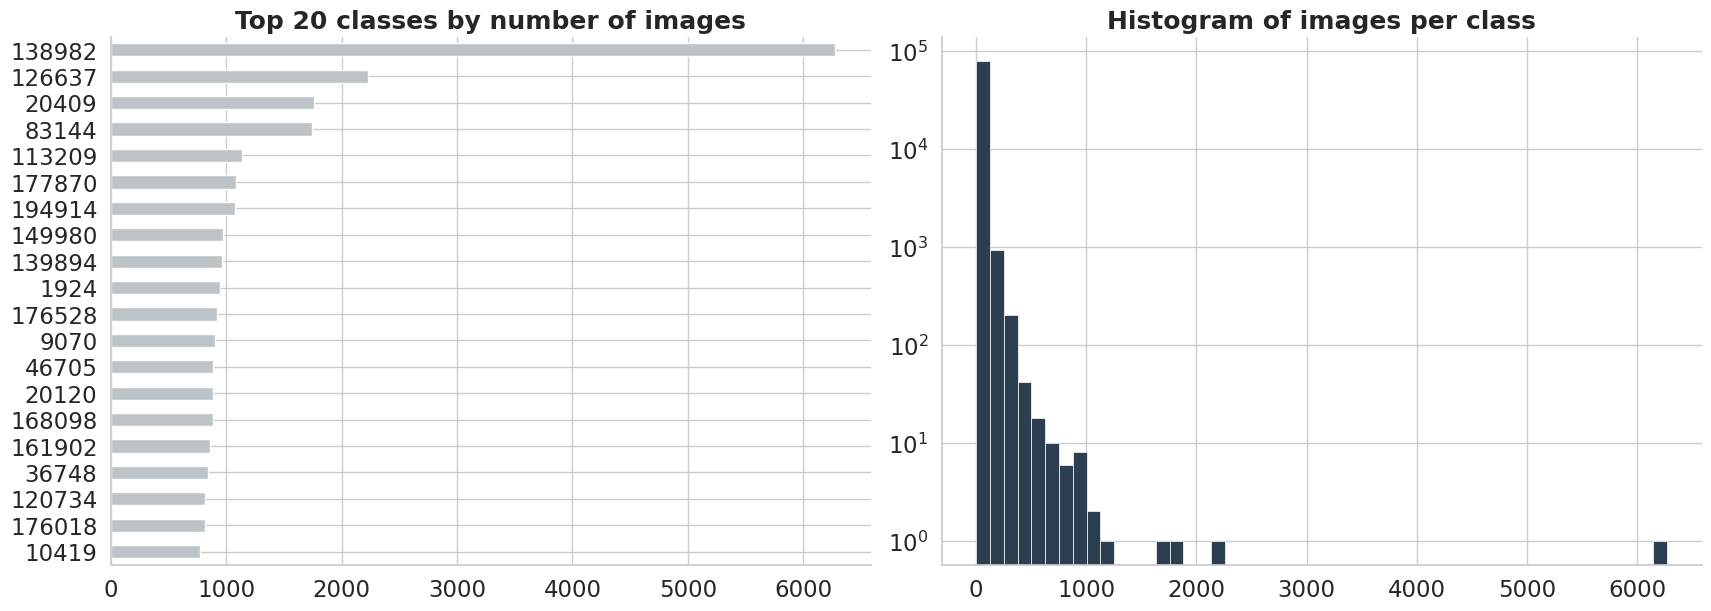

In [163]:
class_counts = train_df['landmark_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)

top20 = class_counts.head(20)

top20.sort_values().plot(kind='barh', ax=axes[0], color='#BDC3C7')
axes[0].set_title('Top 20 classes by number of images', fontweight='bold')
axes[0].yaxis.label.set_visible(False)

axes[1].hist(class_counts.values, bins=50, log=True,
             color='#2c3e50', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of images per class', fontweight='bold')

sns.despine()

plt.show()

In [164]:
def id_to_path(root: Path, img_id: str) -> Path:
    return root / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"

In [165]:
def load_image(path: Path):
    try:
        img = Image.open(path)
        img = ImageOps.exif_transpose(img)
        return img.convert("RGB")
    except:
        return None

In [166]:
def show_random_images(df, root_dir: Path, n=5, max_cols=5):
    ids = random.sample(list(df['id']), n)

    loaded = []
    for img_id in ids:
        path = id_to_path(root_dir, img_id)
        img = load_image(path)
        loaded.append((img_id, img))

    n_images = len(loaded)

    ncols = min(max_cols, n_images)
    nrows = math.ceil(n_images / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), squeeze=False)
    axes = axes.flatten()

    for idx, (img_id, img) in enumerate(loaded):
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(img_id, fontsize=9, pad=6)
        ax.axis('off')

    for ax in axes[n_images:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

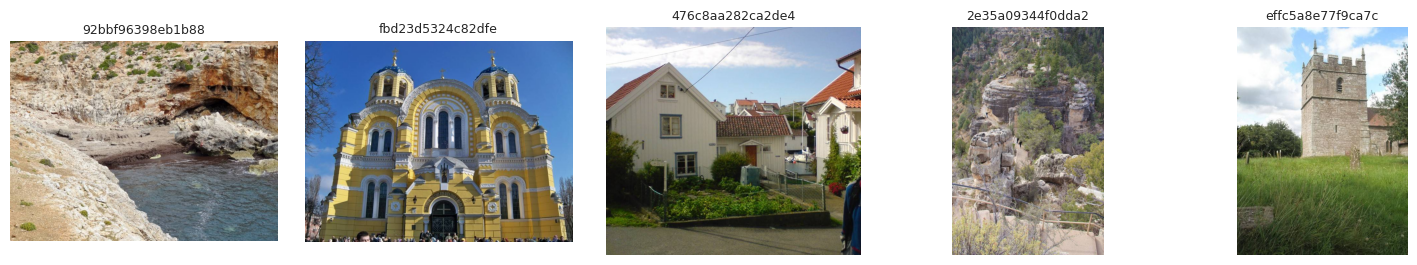

In [167]:
show_random_images(train_df, TRAIN_DIR, n=5)

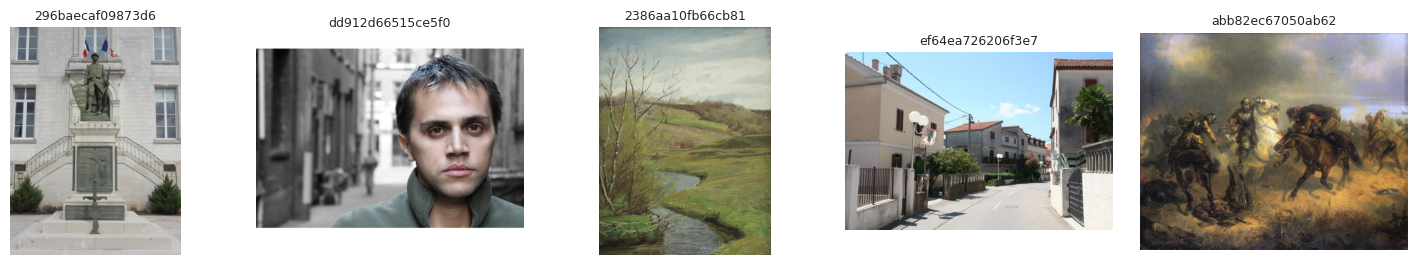

In [168]:
show_random_images(sub_df, TEST_DIR, n=5)

Распределение размеров изображений (случайная выборка 3000 из 1580470)


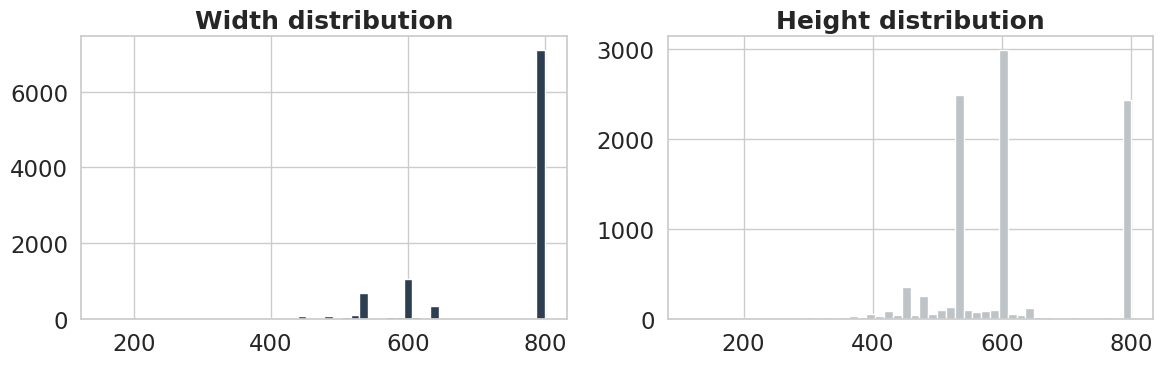

In [169]:
def get_image_size(img_id):
    path = id_to_path(TRAIN_DIR, img_id)
    img = load_image(path)
    return img.size if img else None

print(f"Распределение размеров изображений (случайная выборка 3000 из {len(train_df)})")

sample_ids = train_df["id"].sample(10000, random_state=42)

sizes = [get_image_size(i) for i in sample_ids]
sizes = [s for s in sizes if s is not None]

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, color='#2c3e50')
axes[0].set_title("Width distribution", fontweight='bold' )
axes[1].hist(heights, bins=50, color='#BDC3C7')
axes[1].set_title("Height distribution", fontweight='bold')
plt.tight_layout()
plt.show()

In [170]:
SAMPLE_SIZE = 10000
RANDOM_STATE = 42

random_ids = train_df['id'].sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

min_sides = []
ids_all = []
small_ids = []
for img_id in random_ids:
    with Image.open(id_to_path(TRAIN_DIR, img_id)) as img:
        w, h = img.size
        min_sides.append(min(w, h))
        ids_all.append(img_id)
        if w < 128 or h < 128:
            small_ids.append(img_id)

Отображение изображений с размером min(w, h) < 128


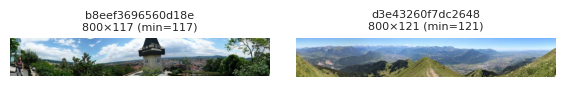

In [171]:
print("Отображение изображений с размером min(w, h) < 128")

random.seed(42)
sample_small = random.sample(small_ids, len(small_ids))

max_cols = 4
cols = min(max_cols, len(sample_small))
rows = int(np.ceil(len(sample_small) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

axes = axes.flatten()

for ax, img_id in zip(axes, sample_small):
    path = id_to_path(TRAIN_DIR, img_id)
    with Image.open(path) as img:
        w, h = img.size
        ax.imshow(img)
        ax.set_title(f"{img_id}\n{w}×{h} (min={min(w, h)})", fontsize=8)
    ax.axis('off')

for ax in axes[len(sample_small):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

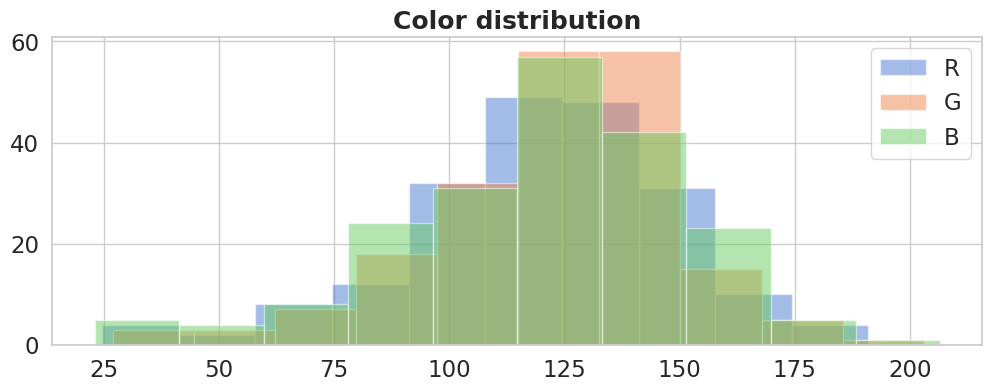

In [172]:
def mean_color(img):
    return np.array(img).mean(axis=(0,1))

colors = []
for img_id in sample_ids[:200]:
    img = load_image(id_to_path(TRAIN_DIR, img_id))
    if img:
        colors.append(mean_color(img))

colors = np.array(colors)

fig, axes = plt.subplots(1, figsize=(12, 4))
plt.hist(colors[:,0], alpha=0.5, label="R")
plt.hist(colors[:,1], alpha=0.5, label="G")
plt.hist(colors[:,2], alpha=0.5, label="B")
plt.legend()
plt.title("Color distribution", fontweight='bold')
plt.show()

100%|██████████| 500/500 [00:08<00:00, 59.69it/s]


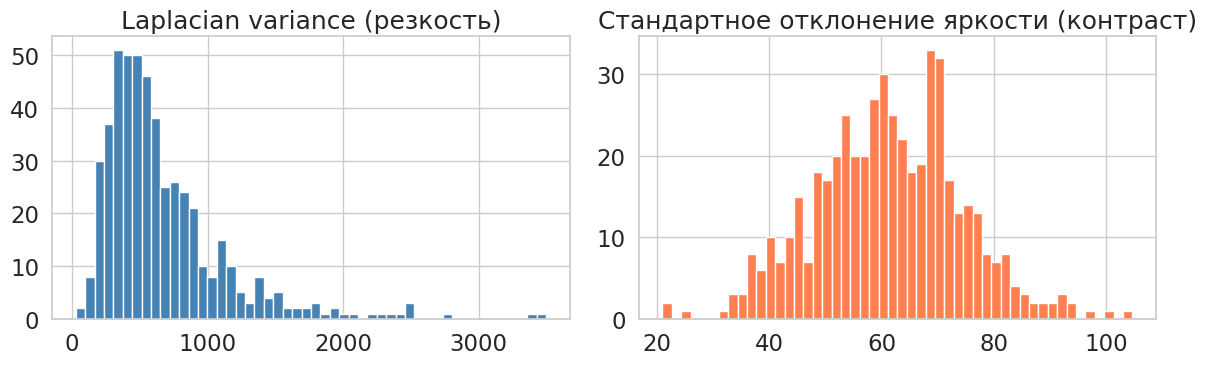

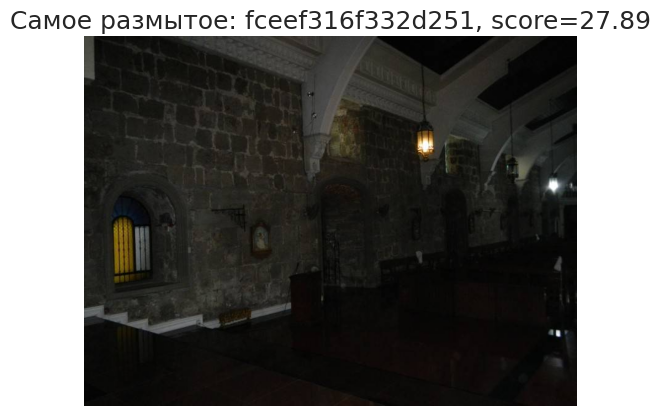

In [178]:

from PIL import ImageFilter   # <-- этот импорт лучше вынести в самый верх, но можно и здесь

def blur_score(image):
    gray = image.convert('L')
    laplacian_kernel = ImageFilter.Kernel(
        (3, 3), [0, 1, 0, 1, -4, 1, 0, 1, 0], scale=1, offset=0
    )
    filtered = gray.filter(laplacian_kernel)
    arr = np.array(filtered)
    return arr.var()

def contrast_score(image):
    gray = image.convert('L')
    arr = np.array(gray)
    return arr.std()

sample = train_df['id'].sample(500, random_state=42)
blur_scores = []
contrast_scores = []
for img_id in tqdm(sample):
    img = load_image(id_to_path(TRAIN_DIR, img_id))
    if img:
        blur_scores.append(blur_score(img))
        contrast_scores.append(contrast_score(img))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(blur_scores, bins=50, color='steelblue')
axes[0].set_title('Laplacian variance (резкость)')
axes[1].hist(contrast_scores, bins=50, color='coral')
axes[1].set_title('Стандартное отклонение яркости (контраст)')
plt.tight_layout()
plt.show()

idx = np.argmin(blur_scores)
blurred_id = sample.iloc[idx]
plt.imshow(load_image(id_to_path(TRAIN_DIR, blurred_id)))
plt.title(f"Самое размытое: {blurred_id}, score={blur_scores[idx]:.2f}")
plt.axis('off')
plt.show()

In [176]:
def analyze_color_distribution(train_df, TRAIN_DIR, id_col='id',
                               gray_thresh=5, desat_thresh=40):
    """
    Анализ цветности изображений из train_df по колонке id_col.
    TRAIN_DIR — корень датасета.
    Ничего не добавляет в train_df, только выводит статистику и график.
    """
    means = []
    labels = []
    errors = 0

    # Сбор данных
    for img_id in tqdm(train_df[id_col], desc="Analyzing"):
        path = id_to_path(TRAIN_DIR, str(img_id))
        img = load_image(path)
        if img is None:
            errors += 1
            continue

        # конвертация в HSV и средняя насыщенность
        hsv = img.convert("HSV")
        S = np.array(hsv)[:, :, 1]
        mean_S = np.mean(S)

        # классификация
        if mean_S < gray_thresh:
            lbl = "gray"
        elif mean_S < desat_thresh:
            lbl = "desaturated"
        else:
            lbl = "color"

        means.append(mean_S)
        labels.append(lbl)

    if not means:
        print("Не удалось загрузить ни одного изображения.")
        return None, None, None

    means = np.array(means)
    total = len(means)
    gray_count = labels.count("gray")
    desat_count = labels.count("desaturated")
    color_count = labels.count("color")

    print(f"Успешно обработано: {total} (ошибок чтения: {errors})")
    print(f"Полностью чёрно-белые  (S < {gray_thresh}):   {gray_count:5d}  ({100 * gray_count / total:.1f}%)")
    print(f"Сильно обесцвеченные    ({gray_thresh} ≤ S < {desat_thresh}): {desat_count:5d}  ({100 * desat_count / total:.1f}%)")
    print(f"Полноцветные           (S ≥ {desat_thresh}): {color_count:5d}  ({100 * color_count / total:.1f}%)")
    print(f"Суммарно обесцвеченных  (gray+desaturated): {gray_count + desat_count:5d}  ({100 * (gray_count + desat_count) / total:.1f}%)")

    ax = plt.gca()                     # получаем текущие оси
    ax.set_title('Новый заголовок')
    ax.set_xlabel('Новая ось X')
    ax.set_ylabel('Новая ось Y')
    ax.legend(['Метка 1', 'Метка 2'])  # при необходимости
    plt.draw()                         # обновить отображение

    return means, labels, (gray_count, desat_count, color_count)

In [177]:
means, labels, counts = analyze_color_distribution(
    train_df, TRAIN_DIR, id_col='id'
)

Analyzing:   0%|          | 524/1580470 [00:09<8:07:38, 54.00it/s]


KeyboardInterrupt: 

In [ ]:
def show_landmark(df, root_dir: Path, landmark_id, num=6):
    subset = df[df["landmark_id"] == landmark_id]

    if len(subset) == 0:
        print("No images for this landmark")
        return

    num = min(num, len(subset))
    sample = subset.sample(num)

    fig, axes = plt.subplots(1, num, figsize=(3 * num, 3))

    if num == 1:
        axes = [axes]

    for i, row in enumerate(sample.itertuples()):
        img = load_image(id_to_path(root_dir, row.id))
        if img:
            axes[i].imshow(img)
        axes[i].axis("off")

    plt.show()

In [ ]:
example_landmark = counts.index[0]
show_landmark(train_df, TRAIN_DIR, example_landmark)

In [ ]:
import imagehash
from tqdm import tqdm

def find_duplicates(df, root_dir: Path, sample_size=1000):
    hashes = {}
    duplicates = []

    sample_ids = df["id"].sample(min(sample_size, len(df)), random_state=42)

    for img_id in tqdm(sample_ids):
        path = id_to_path(root_dir, img_id)
        img = load_image(path)

        if img is None:
            continue

        h = imagehash.phash(img)

        if h in hashes:
            duplicates.append((img_id, hashes[h]))
        else:
            hashes[h] = img_id

    return duplicates

In [ ]:
dups = find_duplicates(train_df, TRAIN_DIR, sample_size=1000)
print("Found duplicates:", len(dups))
dups[:5]

In [ ]:
print("Классов до:", train_df['id'].nunique())

In [ ]:
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("resnet34", pretrained=True, num_classes=0)
model = model.to(device)
model.eval()

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
@torch.no_grad()
def get_embedding(img):
    x = transform(img).unsqueeze(0).to(device)
    emb = model(x)
    emb = torch.nn.functional.normalize(emb, dim=1)
    return emb.cpu().numpy()[0]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(df, root_dir: Path, query_id, top_k=5):
    query_img = load_image(id_to_path(root_dir, query_id))
    query_emb = get_embedding(query_img)

    embs = []
    ids = []

    sample_ids = df["id"].sample(300)  # ускорение

    for img_id in sample_ids:
        img = load_image(id_to_path(root_dir, img_id))
        if img is None:
            continue

        embs.append(get_embedding(img))
        ids.append(img_id)

    sims = cosine_similarity([query_emb], embs)[0]

    top_idx = np.argsort(-sims)[:top_k]

    return [(ids[i], sims[i]) for i in top_idx]

In [ ]:
def show_similar(query_id, results, root_dir: Path):
    plt.figure(figsize=(12,4))

    img = load_image(id_to_path(root_dir, query_id))
    plt.subplot(1, len(results)+1, 1)
    plt.imshow(img)
    plt.title("QUERY")
    plt.axis("off")

    for i, (img_id, score) in enumerate(results):
        img = load_image(id_to_path(root_dir, img_id))

        plt.subplot(1, len(results)+1, i+2)
        if img:
            plt.imshow(img)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.show()

In [ ]:
query = train_df["id"].iloc[0]

results = find_similar(train_df, TRAIN_DIR, query)

show_similar(query, results, TRAIN_DIR)